In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

In [2]:
df = pd.read_csv("used_cars.csv")
df.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


## Data Cleaning

In [4]:
before = len(df)

In [5]:
df['price'] = df['price'].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype("int")
df['price'].sort_values(ascending=False).head(15).values

array([2954083, 1950995, 1599000,  749950,  695000,  649999,  599995,
        599000,  491836,  489995,  489000,  488880,  479995,  469900,
        449995])

In [6]:
for cap in [150_000, 200_000, 250_000, 500_000, 1_590_000]:
    dropped = (df['price'] > cap).sum()
    print(f"cap ${cap:>9,}  drops {dropped:>3} cars  ({dropped/len(df)*100:.1f}%)")

cap $  150,000  drops 118 cars  (2.9%)
cap $  200,000  drops  75 cars  (1.9%)
cap $  250,000  drops  48 cars  (1.2%)
cap $  500,000  drops   8 cars  (0.2%)
cap $1,590,000  drops   3 cars  (0.1%)


In [7]:
cap = 200_000
df = df[df['price'] <= cap].copy()
print(f"Dropped {before - len(df)} rows above ${cap:,}; {len(df)} remain")

Dropped 75 rows above $200,000; 3934 remain


In [8]:
df['accident'] = df['accident'].fillna('Unknown')

In [9]:
df['clean_title'] = df['clean_title'].fillna('No')

In [10]:
mask = df['fuel_type'].isna()
df.loc[mask & df['engine'].str.contains('Electric', case=False, na=False), 'fuel_type'] = 'Electric'
df['fuel_type'] = df['fuel_type'].fillna('Unknown')

In [11]:
df['milage'] = df['milage'].str.replace(" mi.", "", regex=False).str.replace(",", "", regex=False).astype("int")

In [12]:
mileage_cap = df['milage'].quantile(0.99)
df['milage'] = df['milage'].clip(upper=mileage_cap)

In [13]:
print(df['price'].max())    # should be ≤ 200,000  (not 2,954,083)
print(df['milage'].max())   # should equal the 99th-percentile cap, not ~900k

200000
223420.08000000007


In [14]:
from datetime import datetime

df['model_year'] = datetime.now().year - df['model_year'].astype('int')
df['model_year']

0       13
1        5
2        4
3       11
4        5
        ..
4003     8
4005     4
4006     4
4007     6
4008     6
Name: model_year, Length: 3934, dtype: int64

## Data Preprocessing

In [15]:
import pickle
from sklearn.preprocessing import LabelEncoder

cat_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission',
            'ext_col', 'int_col', 'accident', 'clean_title']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()       
    df[col] = le.fit_transform(df[col])
    encoders[col] = le         

pickle.dump(encoders, open("encoders.pkl", "wb"))

In [16]:
df.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,13,1706,13,51000.0,1,577,16,23,12,0,1,10300
1,18,1151,5,34742.0,3,563,29,166,63,0,1,38005
2,26,1292,4,22372.0,3,539,37,32,12,1,0,54598
3,19,1209,11,88900.0,4,720,22,23,12,1,1,15500
4,3,1192,5,9835.0,3,199,29,106,12,1,0,34999


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3934 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         3934 non-null   int64  
 1   model         3934 non-null   int64  
 2   model_year    3934 non-null   int64  
 3   milage        3934 non-null   float64
 4   fuel_type     3934 non-null   int64  
 5   engine        3934 non-null   int64  
 6   transmission  3934 non-null   int64  
 7   ext_col       3934 non-null   int64  
 8   int_col       3934 non-null   int64  
 9   accident      3934 non-null   int64  
 10  clean_title   3934 non-null   int64  
 11  price         3934 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 399.5 KB


In [26]:
## Exploratory Data Analysis (EDA)

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

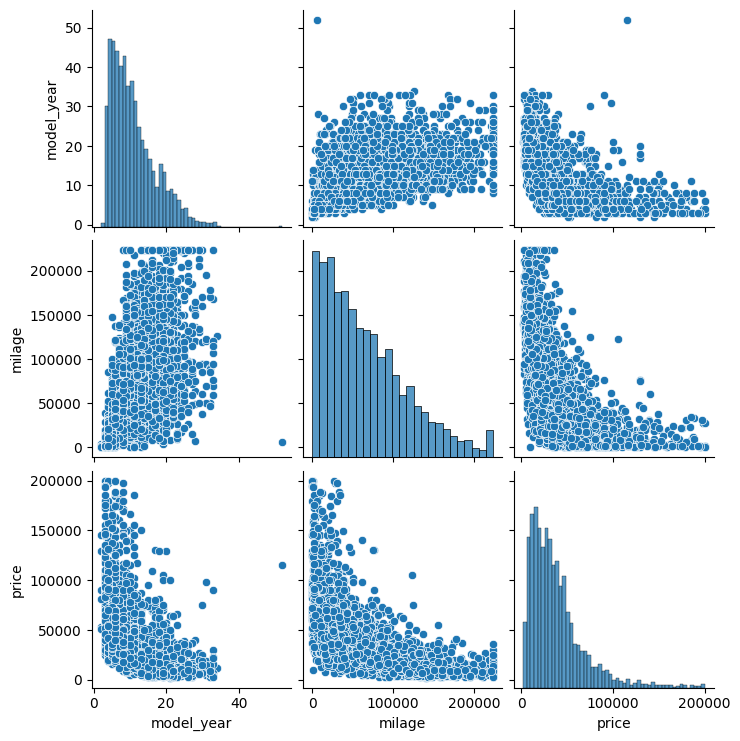

In [19]:
sns.pairplot(df[['model_year', 'milage', 'price']])
plt.show()

In [20]:
df['price'] = np.log1p(df['price'])
df[['model_year', 'milage', 'price']].corr()                # exact relationship strengths

,model_year,milage,price
model_year,1.000000,0.624421,-0.658615
milage,0.624421,1.000000,-0.725326
price,-0.658615,-0.725326,1.000000


## Data Splitting

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X = df.drop(columns='price')
y = df['price']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape)

(3147, 11) (787, 11)


## Training and Testing

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [25]:
def train_and_evaluate(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    y_true = np.expm1(y_test)
    y_pred = np.expm1(preds)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_test, preds)

    print(f"{name:15s}  MAE ${mae:,.0f}   RMSE ${rmse:,.0f}   R² {r2:.3f}")
    return model

lr = train_and_evaluate("linear", LinearRegression(), X_train, X_test, y_train, y_test)
rf = train_and_evaluate("random forest", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test)

linear           MAE $10,685   RMSE $18,551   R² 0.757
random forest    MAE $7,966   RMSE $13,670   R² 0.826


In [28]:
bundle = {
    'model': rf,
    'encoders': encoders,
    'price_cap': 200_000,
    'mileage_cap': mileage_cap,
    'feature_order': list(X.columns),
}
with open("car_price_model.pkl", "wb") as f:
    pickle.dump(bundle, f)